In [14]:

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Lasso, Ridge

# Classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score,
    confusion_matrix
)


# ============================================================
# 1. CREATE DATASET
# ============================================================

data = {
    "Hours": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        11, 12, 13, 14, 15
    ],

    "Attendance": [
        50, 52, 55, 60, 65,
        70, 72, 75, 78, 80,
        82, 85, 88, 92, 95
    ],

    "Age": [
        18, 18, 19, 19, 20,
        20, 21, 21, 22, 22,
        23, 23, 24, 24, 25
    ],

    "Marks": [
        35, 38, 42, 45, 50,
        55, 60, 65, 70, 74,
        78, 82, 86, 90, 95
    ]
}

df = pd.DataFrame(data)

print("=" * 60)
print("DATASET")
print("=" * 60)

print(df)


# ============================================================
# 2. LINEAR REGRESSION
# ============================================================

print("\n")
print("=" * 60)
print("1. LINEAR REGRESSION")
print("=" * 60)

X_reg = df[["Hours", "Attendance"]]
y_reg = df["Marks"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

linear_pred = linear_model.predict(X_test_reg)

print("Actual Values:")
print(y_test_reg.values)

print("\nPredicted Values:")
print(linear_pred)

linear_r2 = r2_score(y_test_reg, linear_pred)
print("\nR2 Score:", linear_r2)

print("Mean Squared Error:",
      mean_squared_error(y_test_reg, linear_pred))


# ============================================================
# 3. LOGISTIC REGRESSION
# ============================================================

print("\n")
print("=" * 60)
print("2. LOGISTIC REGRESSION")
print("=" * 60)

# Create Pass/Fail target
df["Pass"] = np.where(df["Marks"] >= 50, 1, 0)

X_class = df[["Hours", "Attendance", "Age"]]
y_class = df["Pass"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

logistic_model = LogisticRegression()

logistic_model.fit(X_train_class, y_train_class)

logistic_pred = logistic_model.predict(X_test_class)

print("Actual:")
print(y_test_class.values)

print("\nPredicted:")
print(logistic_pred)

logistic_accuracy = accuracy_score(y_test_class, logistic_pred)
print("\nAccuracy:", logistic_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, logistic_pred))


# ============================================================
# 4. K-NEAREST NEIGHBORS
# ============================================================

print("\n")
print("=" * 60)
print("3. K-NEAREST NEIGHBORS")
print("=" * 60)

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Scaling
scaler_knn = StandardScaler()

X_train_scaled_knn = scaler_knn.fit_transform(X_train_knn)
X_test_scaled_knn = scaler_knn.transform(X_test_knn)

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train_scaled_knn, y_train_knn)

knn_pred = knn_model.predict(X_test_scaled_knn)

print("Actual:")
print(y_test_knn.values)

print("\nPredicted:")
print(knn_pred)

knn_accuracy = accuracy_score(y_test_knn, knn_pred)
print("\nAccuracy:", knn_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_knn, knn_pred))


# ============================================================
# 5. DECISION TREE
# ============================================================

print("\n")
print("=" * 60)
print("4. DECISION TREE")
print("=" * 60)

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

decision_tree.fit(X_train_tree, y_train_tree)

tree_pred = decision_tree.predict(X_test_tree)

print("Actual:")
print(y_test_tree.values)

print("\nPredicted:")
print(tree_pred)

tree_accuracy = accuracy_score(y_test_tree, tree_pred)
print("\nAccuracy:", tree_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_tree, tree_pred))


# ============================================================
# 6. RANDOM FOREST
# ============================================================

print("\n")
print("=" * 60)
print("5. RANDOM FOREST")
print("=" * 60)

X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train_forest, y_train_forest)

forest_pred = random_forest.predict(X_test_forest)

print("Actual:")
print(y_test_forest.values)

print("\nPredicted:")
print(forest_pred)

forest_accuracy = accuracy_score(y_test_forest, forest_pred)
print("\nAccuracy:", forest_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_forest, forest_pred))

# Feature importance
print("\nFeature Importance:")

for feature, importance in zip(
        X_class.columns,
        random_forest.feature_importances_):

    print(feature, ":", importance)


# ============================================================
# 7. SUPPORT VECTOR MACHINE
# ============================================================

print("\n")
print("=" * 60)
print("6. SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Scaling
scaler_svm = StandardScaler()

X_train_scaled_svm = scaler_svm.fit_transform(X_train_svm)
X_test_scaled_svm = scaler_svm.transform(X_test_svm)

svm_model = SVC(
    kernel="rbf",
    C=1.0
)

svm_model.fit(X_train_scaled_svm, y_train_svm)

svm_pred = svm_model.predict(X_test_scaled_svm)

print("Actual:")
print(y_test_svm.values)

print("\nPredicted:")
print(svm_pred)

svm_accuracy = accuracy_score(y_test_svm, svm_pred)
print("\nAccuracy:", svm_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_svm, svm_pred))


# ============================================================
# 8. NAIVE BAYES
# ============================================================

print("\n")
print("=" * 60)
print("7. NAIVE BAYES")
print("=" * 60)

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

naive_bayes = GaussianNB()

naive_bayes.fit(X_train_nb, y_train_nb)

nb_pred = naive_bayes.predict(X_test_nb)

print("Actual:")
print(y_test_nb.values)

print("\nPredicted:")
print(nb_pred)

nb_accuracy = accuracy_score(y_test_nb, nb_pred)
print("\nAccuracy:", nb_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_nb, nb_pred))


# ============================================================
# 9. LASSO REGRESSION
# ============================================================

print("\n")
print("=" * 60)
print("8. LASSO REGRESSION")
print("=" * 60)

X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_lasso, y_train_lasso)

lasso_pred = lasso_model.predict(X_test_lasso)

print("Actual:")
print(y_test_lasso.values)

print("\nPredicted:")
print(lasso_pred)

lasso_r2 = r2_score(y_test_lasso, lasso_pred)
print("\nR2 Score:", lasso_r2)

print("Mean Squared Error:",
      mean_squared_error(y_test_lasso, lasso_pred))

print("\nCoefficients:")

for feature, coefficient in zip(
        X_reg.columns,
        lasso_model.coef_):

    print(feature, ":", coefficient)


# ============================================================
# 10. RIDGE REGRESSION
# ============================================================

print("\n")
print("=" * 60)
print("9. RIDGE REGRESSION")
print("=" * 60)

X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_ridge, y_train_ridge)

ridge_pred = ridge_model.predict(X_test_ridge)

print("Actual:")
print(y_test_ridge.values)

print("\nPredicted:")
print(ridge_pred)

ridge_r2 = r2_score(y_test_ridge, ridge_pred)
print("\nR2 Score:", ridge_r2)

print("Mean Squared Error:",
      mean_squared_error(y_test_ridge, ridge_pred))

print("\nCoefficients:")

for feature, coefficient in zip(
        X_reg.columns,
        ridge_model.coef_):

    print(feature, ":", coefficient)


# ============================================================
# FINAL COMPARISON
# ============================================================

print("\n")
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

print("\nClassification Models:")

print("Logistic Regression :", logistic_accuracy)
print("KNN                 :", knn_accuracy)
print("Decision Tree       :", tree_accuracy)
print("Random Forest       :", forest_accuracy)
print("SVM                 :", svm_accuracy)
print("Naive Bayes         :", nb_accuracy)

print("\nRegression Models:")

print("Linear Regression   : R2 =", linear_r2)
print("Lasso Regression    : R2 =", lasso_r2)
print("Ridge Regression    : R2 =", ridge_r2)

print("\n")
print("=" * 60)
print("=" * 60)


DATASET
    Hours  Attendance  Age  Marks
0       1          50   18     35
1       2          52   18     38
2       3          55   19     42
3       4          60   19     45
4       5          65   20     50
5       6          70   20     55
6       7          72   21     60
7       8          75   21     65
8       9          78   22     70
9      10          80   22     74
10     11          82   23     78
11     12          85   23     82
12     13          88   24     86
13     14          92   24     90
14     15          95   25     95


1. LINEAR REGRESSION
Actual Values:
[74 82 35]

Predicted Values:
[73.02520407 81.80910783 32.97565516]

R2 Score: 0.9959794631382032
Mean Squared Error: 1.6948796504063417


2. LOGISTIC REGRESSION
Actual:
[0 1 1]

Predicted:
[0 1 1]

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]


3. K-NEAREST NEIGHBORS
Actual:
[0 1 1]

Predicted:
[0 1 1]

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]


4. DECISION TREE
Actual:
[0 1 1]

Predicted:
[0 1 1


FINAL MODEL COMPARISON
Logistic Regression : 100.0 %
SVM : 100.0 %
Naive Bayes : 100.0 %
Decision Tree : 100.0 %
Random Forest : 100.0 %
Linear Regression : 99.6 %
Lasso Regression : 99.58 %
Ridge Regression : 99.51 %

BEST MODEL
Logistic Regression with 100.0 %


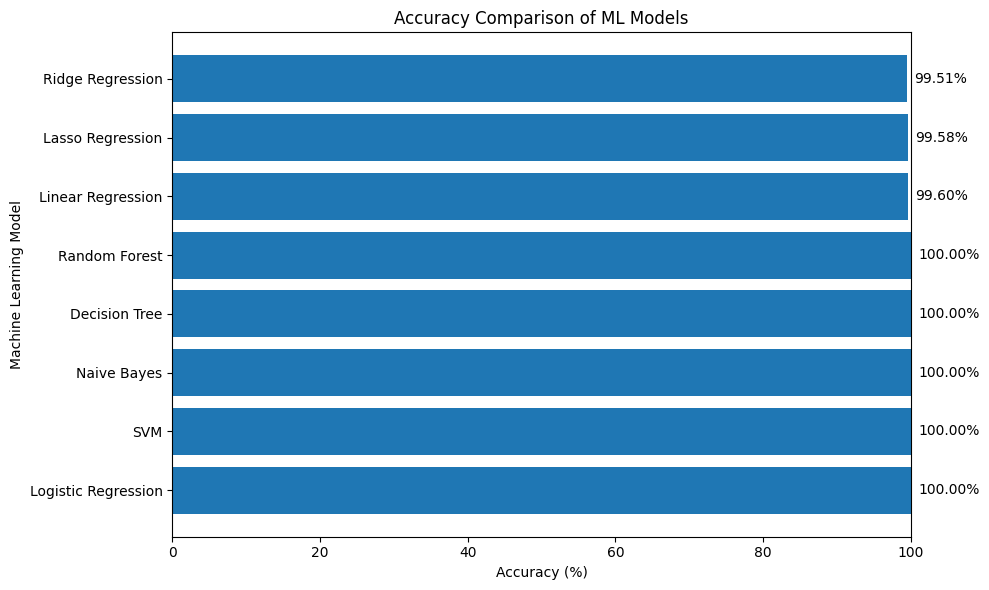

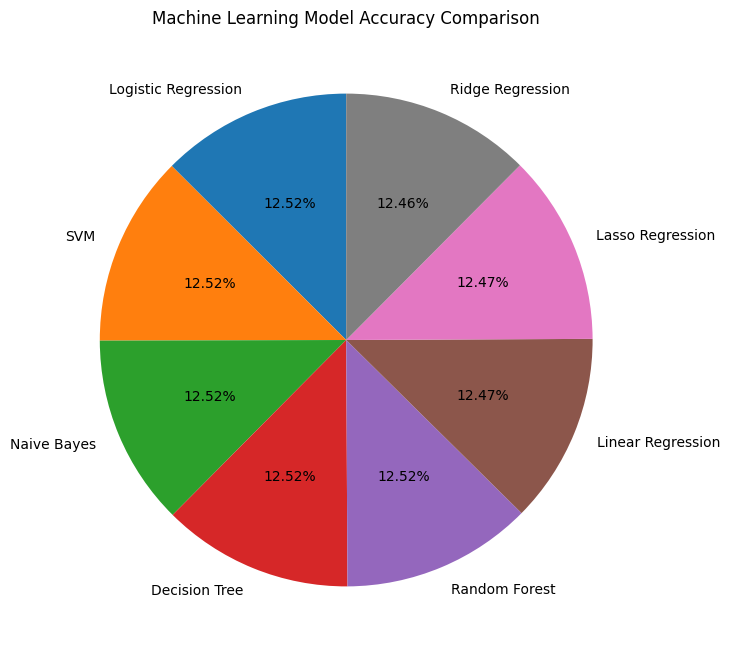

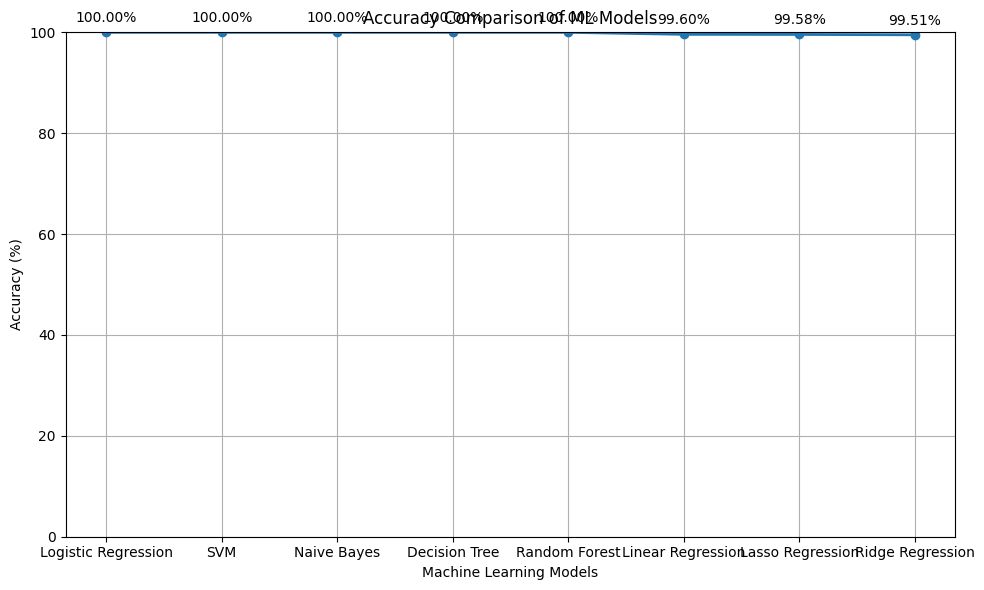

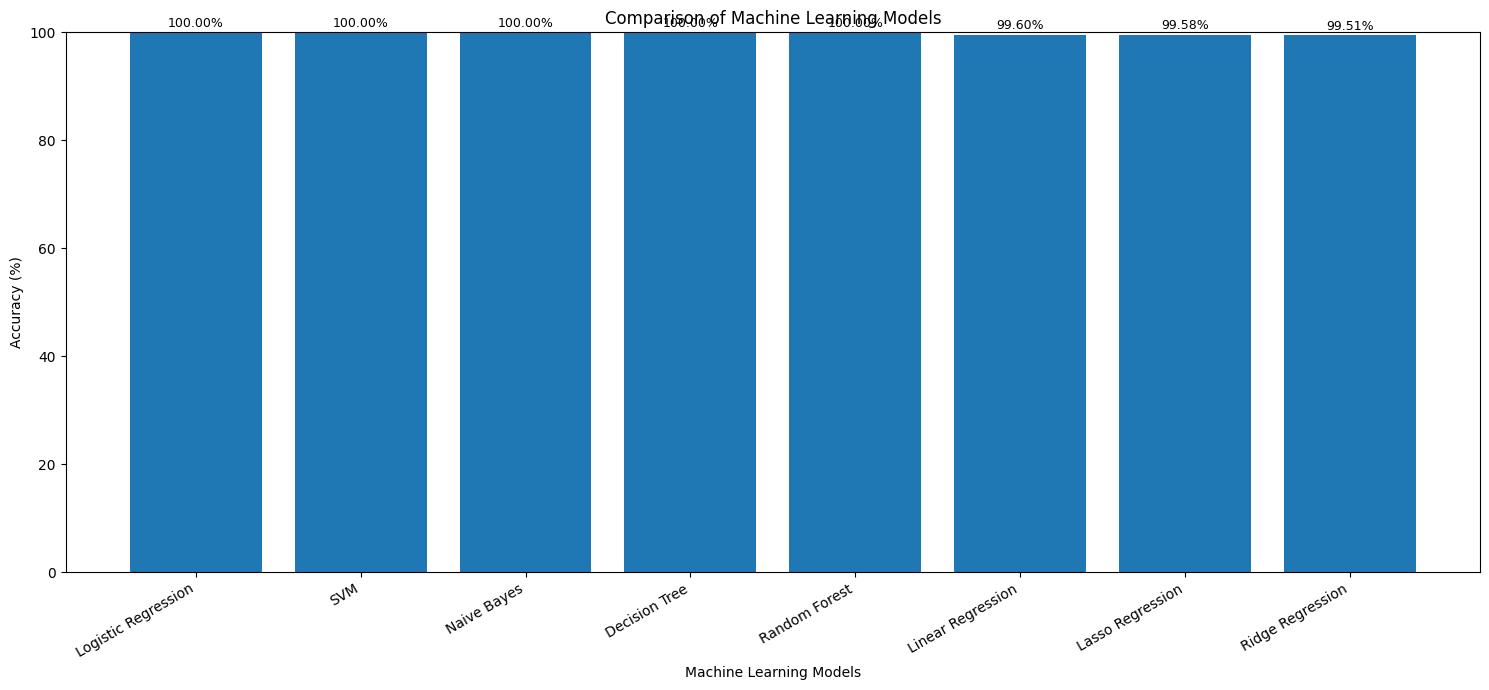

In [13]:
 # ============================================
# 16. STORE ALL ACCURACIES
# ============================================

model_names = [
    "Logistic Regression",
    "SVM",
    "Naive Bayes",
    "Decision Tree",
    "Random Forest",
    "Linear Regression",
    "Lasso Regression",
    "Ridge Regression"
]


accuracies = [
    logistic_accuracy * 100,
    svm_accuracy * 100,
    nb_accuracy * 100,
    tree_accuracy * 100,
    forest_accuracy * 100,
    # kmeans_accuracy * 100, # K-Means is an unsupervised learning model, does not have accuracy.
    linear_r2 * 100, # Linear Regression, Lasso and Ridge give R2 score.
    lasso_r2 * 100,
    ridge_r2 * 100
]


# ============================================
# 17. FINAL MODEL COMPARISON
# ============================================

print("\n================================")
print("FINAL MODEL COMPARISON")
print("================================")

for name, accuracy in zip(
    model_names,
    accuracies
):

    print(
        name,
        ":",
        round(accuracy, 2),
        "%"
    )


# ============================================
# 18. FIND BEST MODEL
# ============================================

best_index = accuracies.index(
    max(accuracies)
)

best_model = model_names[best_index]

best_accuracy = accuracies[best_index]


print("\n================================")
print("BEST MODEL")
print("================================")

print(
    best_model,
    "with",
    round(best_accuracy, 2),
    "%"
)
# ============================================
# ALTERNATIVE GRAPH - HORIZONTAL BAR CHART
# ============================================

plt.figure(figsize=(10, 6))

bars = plt.barh(
    model_names,
    accuracies
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")

plt.title("Accuracy Comparison of ML Models")

plt.xlim(0, 100)

# Show accuracy value at the end of each bar
for bar, accuracy in zip(bars, accuracies):

    plt.text(
        accuracy + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.show()

# ============================================
# PIE CHART - MODEL ACCURACY COMPARISON
# ============================================

plt.figure(figsize=(8, 8))

plt.pie(
    accuracies,
    labels=model_names,
    autopct="%.2f%%",
    startangle=90
)

plt.title("Machine Learning Model Accuracy Comparison")

plt.show()

# ============================================
# LINE GRAPH - MODEL ACCURACY COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    model_names,
    accuracies,
    marker="o",
    linewidth=2
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison of ML Models")

plt.ylim(0, 100)

# Display accuracy values
for i, accuracy in enumerate(accuracies):

    plt.text(
        i,
        accuracy + 2,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================
# 19. GRAPHICAL REPRESENTATION
# ============================================

plt.figure(
    figsize=(15, 7)
)

bars = plt.bar(
    model_names,
    accuracies
)


plt.xlabel(
    "Machine Learning Models"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Comparison of Machine Learning Models"
)

plt.ylim(
    0,
    100
)


# ============================================
# 20. DISPLAY ACCURACY ON TOP OF BARS
# ============================================

for bar, accuracy in zip(
    bars,
    accuracies
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
        fontsize=9
    )


plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()